# Prezentare

Pneumonia este o afectiune respiratorie comuna, dar serioasa, caracterizata prin inflamarea tesutului pulmonar. Diagnosticarea corecta si rapida este esentiala, deoarece intarzierile in identificarea bolii pot duce la complicatii severe. In practica medicala, radiografiile toracice reprezinta una dintre cele mai folosite metode pentru evaluarea starii plamanilor, iar posibilitatea analizarii automate a acestor imagini poate sprijini procesul de diagnosticare si poate reduce incarcarea personalului medical.

In acest proiect a fost utilizat un dataset format din imagini radiologice clasificate in doua categorii: NORMAL si PNEUMONIA. Dataset-ul include radiografii preprocesate si etichetate manual, fiind frecvent folosit in lucrari academice pentru testarea modelelor de clasificare a imaginilor medicale. Este un set de date dezechilibrat, categoria PNEUMONIA avand un numar mai mare de exemple, ceea ce solicita metode adecvate de ponderare sau augmentare pentru a evita biasul modelului.

Obiectivul proiectului este construirea unui model de deep learning capabil sa identifice automat prezenta pneumoniei in imaginile radiologice. Pentru aceasta a fost utilizata arhitectura VGG16 prin transfer learning, o metoda eficienta care permite reutilizarea caracteristicilor deja invatate pe setul ImageNet. Intregul flux a inclus incarcarea si explorarea datelor, pregatirea imaginilor, augmentarea lor pentru cresterea variabilitatii, definirea modelului, antrenarea si evaluarea performantelor obtinute.

Prin acest proces a fost dezvoltat un sistem complet, capabil sa clasifice radiografiile toracice cu performante ridicate, oferind un punct de plecare solid pentru aplicatii practice sau extinderi ulterioare.

 ## 1. Import-uri

In [38]:
# Biblioteci generale

import random
import os                           # Pentru lucrul cu fisiere
import numpy as np                  # Pentru operatii numerice avansate
import matplotlib.pyplot as plt     # Pentru vizualarea datelor
import seaborn as sns               # Pentru vizualizarea datelor
from PIL import Image               # Pentru manipularea imaginilor
import cv2                          # Pentru manipularea imaginilor

# Tensorflow si Leras

import tensorflow as tf # Biblioteca generala pentru deep learning
from tensorflow.keras.models import load_model # Pentru incarcarea modelului salvat
from tensorflow import keras  # API-ul pentru construirea si antrenarea modelelor, integrat in tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Pentru preprocesarea imagiinlor si generarea de batch-uri
from tensorflow.keras.applications import VGG16 # Modelul preantrenat
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model # Clasa pentru definirea modelului
from tensorflow.keras.optimizers import Adam # Optimizator pentru ajustarea ponderilor in timpul antrenamentului
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint # Callback-uri pentru a stopa antrenamentul automat

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # Pentru evaluarea performantelor modelului

# Pentru reproductibilitatea rezultatelor
np.random.seed(42)
tf.random.set_seed(42)

## 2. Vizualizarea datelor

In [39]:
# Asignarea path-urlior dupa noul split
base_dir_split = '../dataset/chest_xray_split'
train_dir = os.path.join(base_dir_split, 'train')
test_dir = os.path.join(base_dir_split, 'test')

print(f"Antrenament : {train_dir}")
print(f"Test: {test_dir}")

Antrenament : ../dataset/chest_xray_split/train
Test: ../dataset/chest_xray_split/test


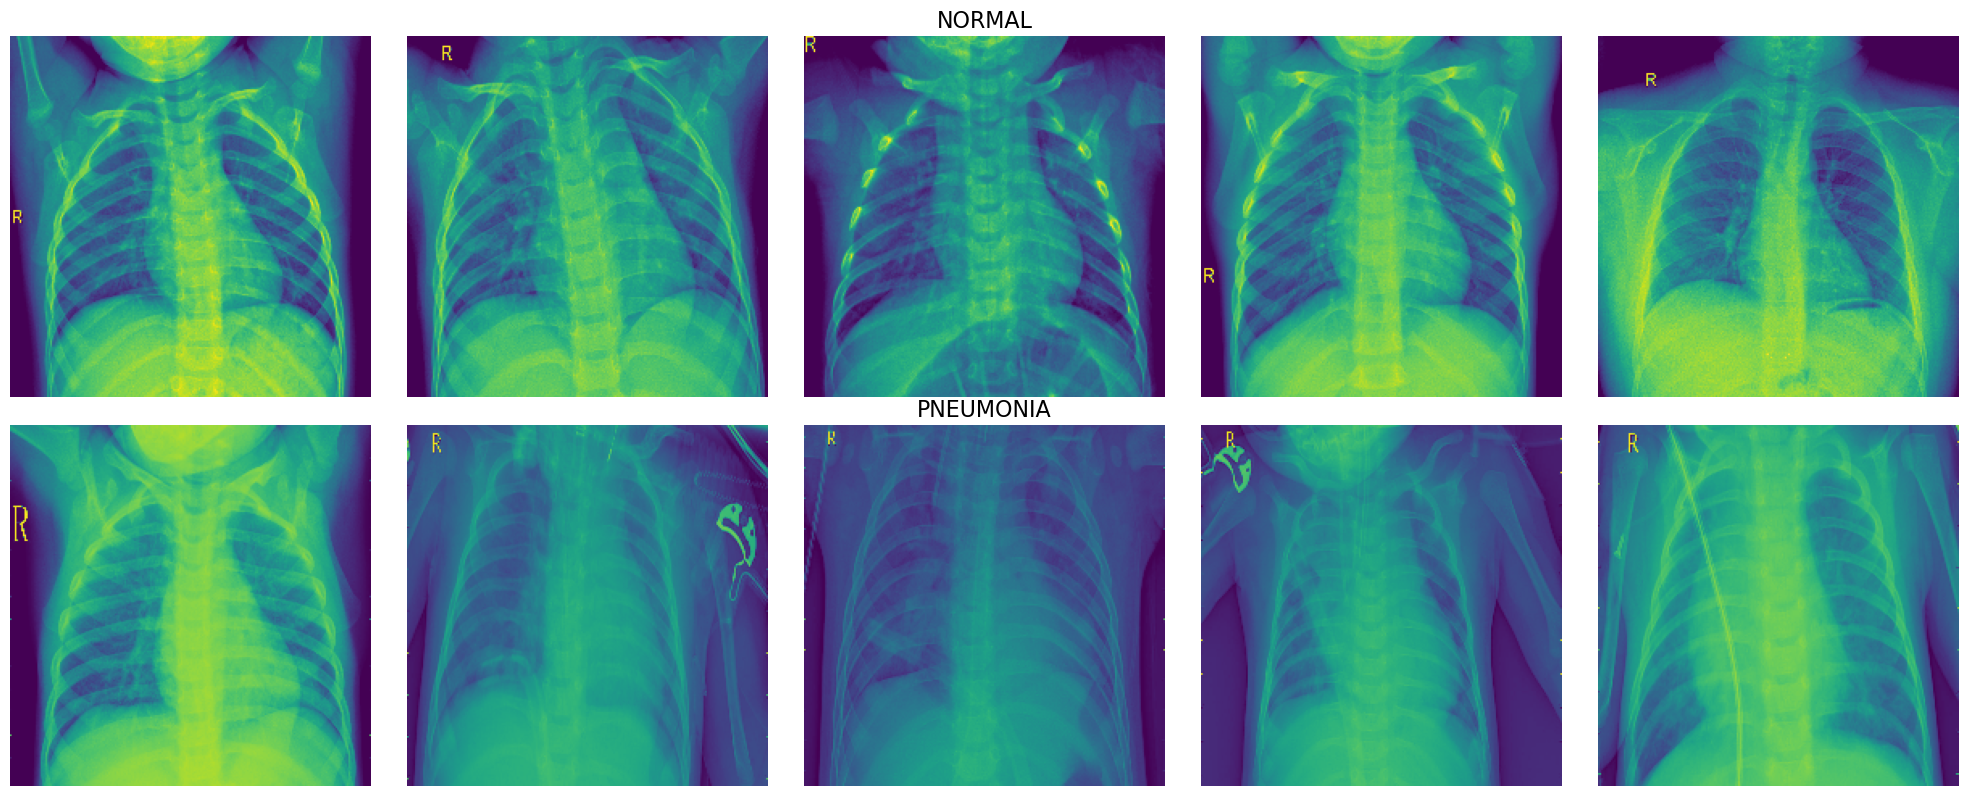

In [40]:
# Vizualizarea radiografiilor

# Setarea path-urilor pentru directoarele cu imagini
normal_dir = '../dataset/chest_xray_split/train/NORMAL'
pneumonia_dir = '../dataset/chest_xray_split/train/PNEUMONIA'

# Selectarea a n imagini aleatorii din fiecare clasă
n_images = 5
normal_paths = random.sample(os.listdir(normal_dir), n_images)   
pneumonia_paths = random.sample(os.listdir(pneumonia_dir), n_images)

# Crearea unei figuri cu 2 randuri si n coloane
fig, axes = plt.subplots(2, n_images, figsize=(20, 8))

# Afisarea imaginilor normale
for i, fname in enumerate(normal_paths):
    path = os.path.join(normal_dir, fname)                 # Setarea path-ului complet
    img = tf.io.read_file(path)                            # Citirea bitilor imaginii (salvati intr-un array)
    img = tf.image.decode_jpeg(img)                        # Decodarea imaginii (matrice de pixeli)
    img = tf.image.resize(img, (224, 224))                 # Redimensionarea imaginii la dimensiunea dorita
    axes[0, i].imshow(tf.cast(img, tf.uint8).numpy())      # Afisarea imaginii in subplot
    axes[0, i].axis("off")                                 # Ascunderea axelor
    if i == n_images // 2:                                 # Daca e imaginea din mijloc
        axes[0, i].set_title("NORMAL", fontsize=16)        # Setarea titlului pentru randul de imagini normale

# Afisarea imaginilor cu pneumonie
for i, fname in enumerate(pneumonia_paths):
    path = os.path.join(pneumonia_dir, fname)              # Setarea path-ului complet
    img = tf.io.read_file(path)                            # Citirea fisierului imaginii
    img = tf.image.decode_jpeg(img)                        # Decodarea imaginii (matrice de pixeli)
    img = tf.image.resize(img, (224, 224))                 # Redimensionarea imaginii
    axes[1, i].imshow(tf.cast(img, tf.uint8).numpy())      # Afisarea imaginii in subplot
    axes[1, i].axis("off")                                 # Ascunderea axelor
    if i == n_images // 2:                                 # Daca e imaginea din mijloc
        axes[1, i].set_title("PNEUMONIA", fontsize=16)     # Setarea titlului pentru randul de imagini cu pneumonie

# Ajustarea automata a spatiului intre subploturi
plt.tight_layout()

# Afisarea figurii cu toate imaginile
plt.show();                                              

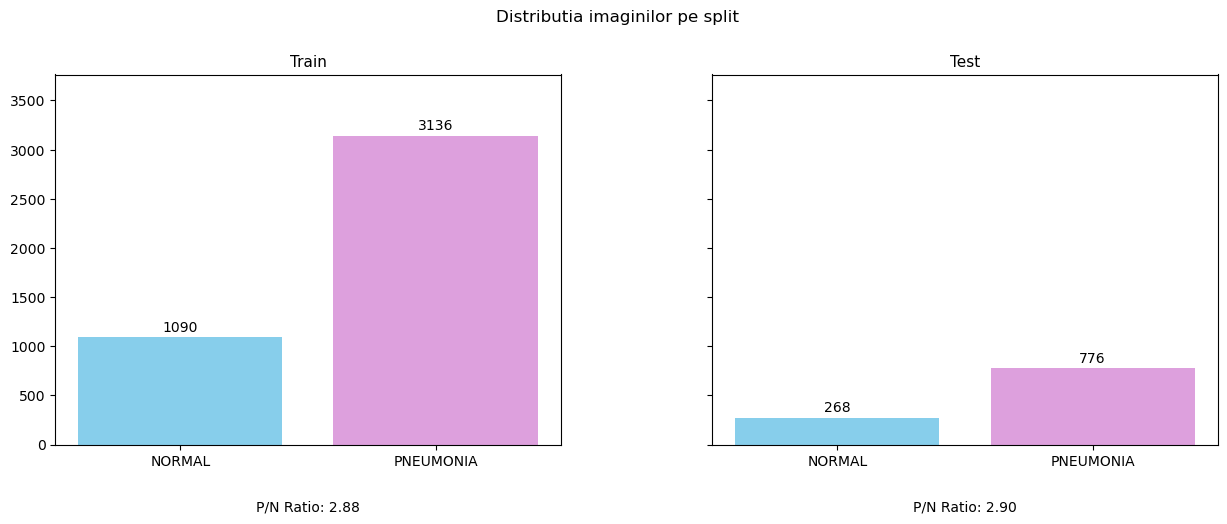

In [42]:
# Crearea graficului de distributie a datelor

def explore_and_plot_distribution(train_dir, test_dir):
    splits = {
        'Train': train_dir,
        'Test': test_dir
    }
    classes = ['NORMAL', 'PNEUMONIA']
    
    # Calcularea ylim pentru ca toate graficele sa aiba aceeasi latime
    max_count = 0
    ratios = {} 
    for split_name, split_path in splits.items():
        counts = []
        # Numararea fisierelor din fiecare clasa
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
            counts.append(count)
            max_count = max(max_count, count)

        # Calcularea ratiilor 
        ratios[split_name] = counts[1] / counts[0] if counts[0] != 0 else float('inf')

    # Crearea figurii  cu un rand si 3 coloane
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for i, (split_name, split_path) in enumerate(splits.items()):
        counts = []
        # Renumararea fisierelor din fiecare director
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
            counts.append(count)

        # Desenarea barelor pentru fiecare clasa
        axes[i].bar(classes, counts, color=['skyblue', 'plum'])
        
        # Scrierea titlului pentru fiecare clasa
        axes[i].set_title(f"{split_name}", fontsize=11)
        
        # Padding de 20% fata de cea mai mare valoare aplicat la fiecare clasa
        axes[i].set_ylim(0, max_count*1.2)
        
        # Scrierea numarului de imagini deasupra feicarei bare
        for j, count in enumerate(counts):
            axes[i].text(j, count + max_count*0.02, str(count), ha='center', fontsize=10)
        
        # Scrierea ratiilor sub axa x
        axes[i].text(0.5, -0.15, f"P/N Ratio: {ratios[split_name]:.2f}", 
                     ha='center', va='top', transform=axes[i].transAxes, fontsize=10)

    # Scrierea titlului graficului
    plt.suptitle("Distributia imaginilor pe split", fontsize=12)
    plt.subplots_adjust(top=0.85, wspace=0.3)
    plt.show()

base_dir_split = '../dataset/chest_xray_split'
train_dir = os.path.join(base_dir_split, 'train')
test_dir = os.path.join(base_dir_split, 'test')

# Apelarea functiei pe path-urile obtinute mai sus
explore_and_plot_distribution(train_dir, test_dir)

# Se observa ca datasetul nu este balansat

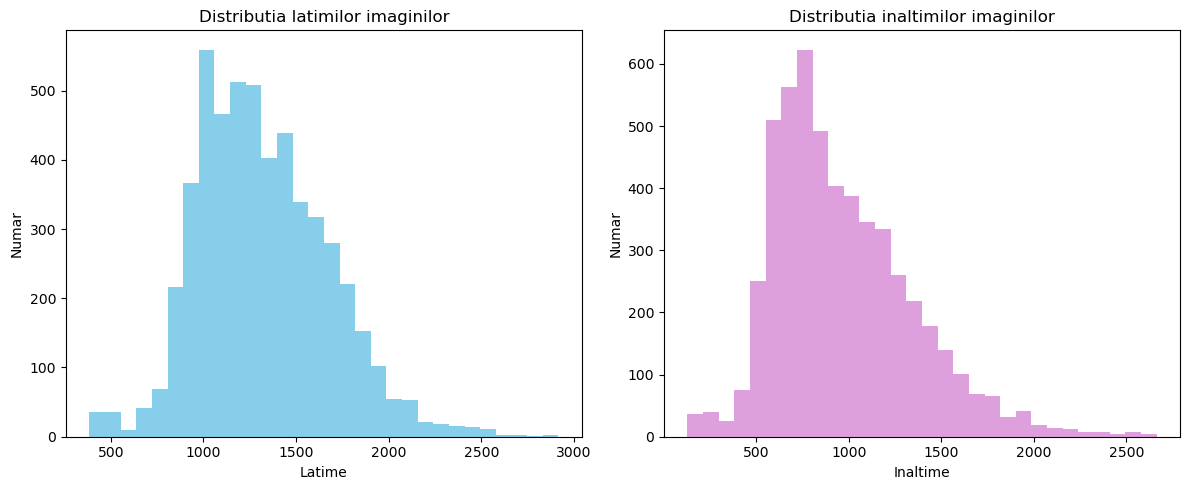

In [44]:
# Vizualizarea dimensiunilor imaginilor

# Colectarea dimensiunilor tuturor imaginilor din train, val si test
image_sizes = []

for split_dir in [train_dir, test_dir]:                 # Iteram prin cele 2 split-uri
    for cls in ['NORMAL', 'PNEUMONIA']:                 # Iteram prin cele 2 clase
        cls_path = os.path.join(split_dir, cls)         # Construim calea catre folderul clasei
        for f in os.listdir(cls_path):                  # Iteram prin fisierele din folder
            path = os.path.join(cls_path, f)            # Construim calea completa catre fisier
            if os.path.isfile(path):                    # Verificam ca e fisier
                img = Image.open(path)                  # Deschidem imaginea cu PIL
                image_sizes.append(img.size)            # Salvam dimensiunea imaginii (width, height)

# Separarea latimilor si inaltimilor in doua liste separate
widths = [w for w, h in image_sizes]    # Lista cu latimile tuturor imaginilor
heights = [h for w, h in image_sizes]   # Lista cu inaltimile tuturor imaginilor

# Plotarea distributiei latimilor si inaltimilor
plt.figure(figsize=(12,5))

# Histograma latimilor
plt.subplot(1,2,1)
plt.hist(widths, bins=30, color='skyblue')      # Crearea histogramelor pentru latimi
plt.title("Distributia latimilor imaginilor")   # Titlul subplotului
plt.xlabel("Latime")                            # Label pentru axa X
plt.ylabel("Numar")                             # Label pentru axa Y

# Histograma inaltimilor
plt.subplot(1,2,2)
plt.hist(heights, bins=30, color='plum')        # Crearea histogramelor pentru inaltimi
plt.title("Distributia inaltimilor imaginilor") # Titlul subplotului
plt.xlabel("Inaltime")                          # Label pentru axa X
plt.ylabel("Numar")                             # Label pentru axa Y

# Ajustarea automata a spatiului intre subploturi
plt.tight_layout()  

# Afisarea graficului
plt.show()                               

## 3. Pregatirea datelor

In [45]:
# Parametri imagini si batch

IMG_HEIGHT = 224          # Inaltimea la care se redimensioneaza imaginile
IMG_WIDTH = 224           # Latimea la care se redimensioneaza imaginile
BATCH_SIZE = 32           # Numarul de imagini procesate simultan in fiecare batch

# Data augmentation pentru train
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalizare pixeli intre 0 si 1
    rotation_range=15,        # Rotatii random de pana la 15 grade
    width_shift_range=0.1,    # Translatii pe orizontala (10%)
    height_shift_range=0.1,   # Translatii pe verticala (10%)
    shear_range=0.1,          # Efect de shear
    zoom_range=0.1,           # Zoom random
    horizontal_flip=True,     # Flip orizontal random
    fill_mode='nearest'       # Umplere pixeli noi dupa transformari
)

# Pentru validare si test doar normalizare
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Crearea generatorului pentru antrenament
train_generator = train_datagen.flow_from_directory(
    train_dir,                             # Directorul cu imaginile de antrenament
    target_size=(IMG_HEIGHT, IMG_WIDTH),   # Redimensionare la 224x224
    batch_size=BATCH_SIZE,                 # Marimea batch-ului
    class_mode='binary',                   # Clasificare binara (NORMAL/PNEUMONIA)
    shuffle=True                           # Amesteca imaginile la fiecare epoch
)

# Crearea generatorului pentru test
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False                          # Nu amestecam testul
)

# Afisarea informatiilor despre clase si numar de imagini
print(f"\nIndicii claselor: {train_generator.class_indices}")    # Mapare nume clasa, label
print(f"Fisiere antrenament: {train_generator.samples}")         # Numar total imagini train
print(f"Fisiere test: {test_generator.samples}")                 # Numar total imagini test

Found 4229 images belonging to 2 classes.
Found 1044 images belonging to 2 classes.

Indicii claselor: {'NORMAL': 0, 'PNEUMONIA': 1}
Fisiere antrenament: 4229
Fisiere test: 1044


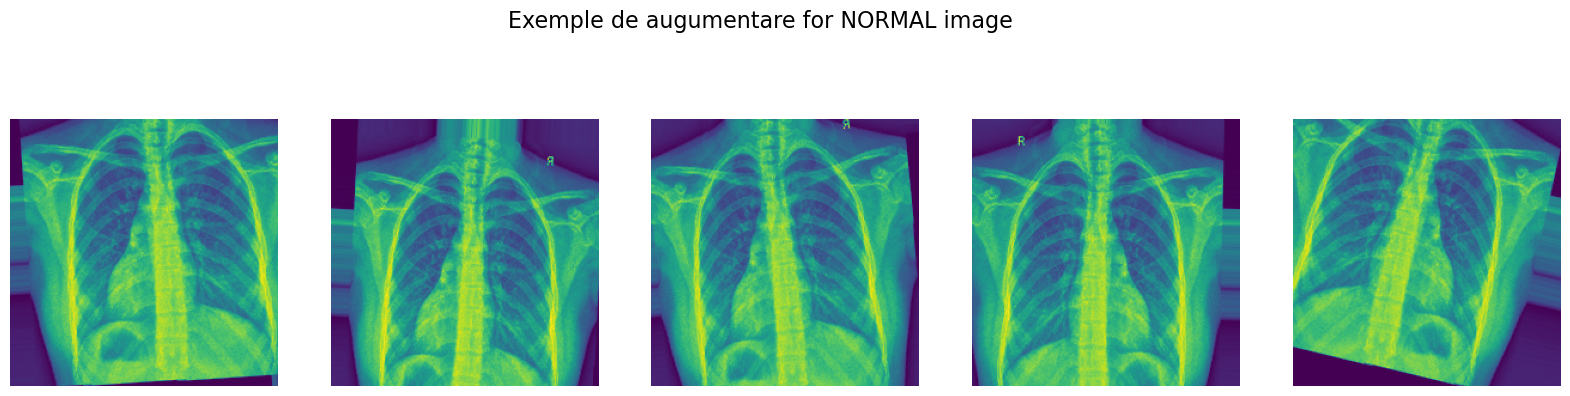

In [46]:
# Exemplu de augumentare

# Selectam o imagine de exemplu din folderul de train
sample_class = 'NORMAL'                                   # Clasa pentru care vizualizam augmentarea
sample_path = os.path.join(train_dir, sample_class)
sample_image = os.listdir(sample_path)[0]                 # Prima imagine din clasa aleasa
img_path = os.path.join(sample_path, sample_image)

# Citirea imaginii
img = tf.io.read_file(img_path)                           # Citim fisierul ca bytes
img = tf.image.decode_jpeg(img, channels = 1)             # Decodam JPEG-ul in matrice de pixeli
img = tf.image.resize(img, (IMG_HEIGHT, IMG_WIDTH))       # Redimensionam la 224x224
img_array = tf.expand_dims(img, 0)                        # Adaugam dimensiune batch-ului (batch_size, height, wifth, channels)

# Crearea generatorului pentru data augmentation
datagen = ImageDataGenerator(
    rescale=1./255,                         # Normalizare pixeli intre 0 si 1
    rotation_range=15,                      # Rotatie random de +/- 15 grade
    width_shift_range=0.1,                  # Translatie pe orizontala pana la 10%
    height_shift_range=0.1,                 # Translatie pe verticala pana la 10%
    shear_range=0.1,                        # Aplicare efect shear
    zoom_range=0.1,                         # Zoom random +/-10%
    horizontal_flip=True,                   # Flip orizontal random
    fill_mode='nearest'                     # Umplere pixeli noi dupa transformari
)

# Pregatim figura pentru vizualizare
fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # 1 rand, 5 coloane

# Generam si afisam 5 imagini augmentate
for i, batch in enumerate(datagen.flow(img_array, batch_size=1)):
    axes[i].imshow(tf.cast(batch[0]*255, tf.uint8).numpy()) # Afisam imaginea (pixeli 0-255)
    axes[i].axis('off')                                     # Fara axe
    if i == 4:                                              # Oprim dupa 5 imagini
        break

plt.suptitle(f"Exemple de augumentare for {sample_class} image", fontsize=16)
plt.show();

## 4. Configurarea modelului

In [47]:
# Construire model Transfer Learning cu VGG16

def build_vgg16_model():
    # VGG16 preantrenat pe ImageNet fara straturile fully connected de la final
    # Transformarea imaginilor de intrare in feature maps prin convolutii preantrenate
    base_model = VGG16(
        weights='imagenet',                     # Folosim greutatile pre-antrenate
        include_top=False,                      # Excludem ultimele straturi Dense
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)  # Dimensiunea imaginilor de intrare
    )
    
    # Blocam straturile convolutive
    # Impiedicam modificarea filtrelor pre-antrenate pentru a pastra cunostintele initiale
    for layer in base_model.layers:
        layer.trainable = False
    
    # Global Average Pooling
    # Acesta transforma feature maps 3D intr-un vector 1D prin calcularea mediei pe fiecare harta de caracteristici
    x = GlobalAveragePooling2D()(base_model.output)
    
    # Dense layer (fiecare neuron este complet conectat la stratul anterior) cu 512 neuroni si activare ReLU (ReLu(x) = max(0, x))
    # Combinam vectorul 1D cu ponderile si bias-ul stratului dense (combinatie vector-matrice) 
    # ReLU activeaza neuronii pozitiv, pastrand valorile negative ca 0
    x = Dense(512, activation='relu')(x)
    
    # Batch Normalization
    x = BatchNormalization()(x)
    
    # Dropout 0.5
    # Eliminam aleator 50% din neuroni pentru a preveni overfitting
    x = Dropout(0.5)(x)
    
    # Dense layer cu 256 neuroni si activare ReLU
    # Transformam din nou vectorul pentru a extrage combinatii mai complexe de feature-uri
    x = Dense(256, activation='relu')(x)
    
    # Batch Normalization
    x = BatchNormalization()(x)
    
    # Dropout 0.3
    # Eliminam aleator 30% din neuroni pentru regularizare suplimentara
    x = Dropout(0.3)(x)
    
    # Strat final de output (predictions)
    # Transformam iesirea intr-o probabilitate intre 0 si 1 cu functia sigmoid
    # Sigmoid comprima valorile reale intr-un interval [0,1], perfect pentru clasificare binara
    predictions = Dense(1, activation='sigmoid')(x)
    
    # Crearea modelului final
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Construim modelul
model = build_vgg16_model()

# Compilarea modelului
model.compile(
    optimizer=Adam(learning_rate=0.0001),           # Ajustam greutatile prin Adam (in timpul antrenamentului)
    loss='binary_crossentropy',                     # Calculam pierderea pentru clasificare binara
    metrics=[
        'accuracy',                                 # Masuram acuratetea generala
        keras.metrics.Precision(name='precision'),  # Calculam cat de corect prezicem clasa pozitiva
        keras.metrics.Recall(name='recall'),        # Calculam cat din clasa pozitiva este detectata
        keras.metrics.AUC(name='auc')               # Masuram capacitatea modelului de separare a claselor
    ]
)

In [48]:
# Callback-uri pentru oprirea antrenamentului

callbacks = [
    EarlyStopping(      # opreste antrenamentul daca loss nu se imbunatateste, asteapta 10 epoci, revine la cele mai bune greutati
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(  # reduce rata de invatare cu factor 0.5 daca loss nu scade timp de 3 epoci
        monitor='loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(    # salveaza modelul cu cea mai buna accuracy
        'bun1.keras',
        monitor='accuracy',
        save_best_only=True,
        verbose=1
    )
]

## 5. Antrenare

In [49]:
# Numararea fisierrelor
num_normal = len([f for f in os.listdir(os.path.join(train_dir, 'NORMAL')) if os.path.isfile(os.path.join(train_dir, 'NORMAL', f))])
num_pneumonia = len([f for f in os.listdir(os.path.join(train_dir, 'PNEUMONIA')) if os.path.isfile(os.path.join(train_dir, 'PNEUMONIA', f))])
total = num_normal + num_pneumonia

# Calcularea ponderilor invers proportionale fata de cel din dataset
class_weight = {
    0: total / (2 * num_normal), 
    1: total / (2 * num_pneumonia)   
}

print(f"Class weights: {class_weight}")

# Antrenare model
EPOCHS = 30            # (de cate ori se parcurge setul de date daca antrenamentul nu este oprit)
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

print("\nAntrenament finalizat")

Class weights: {0: 1.9385321100917432, 1: 0.6737882653061225}
Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.7143 - auc: 0.8603 - loss: 0.4975 - precision: 0.9327 - recall: 0.6633
Epoch 1: accuracy improved from None to 0.77418, saving model to bun1.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 28s 201ms/step - accuracy: 0.7742 - auc: 0.9189 - loss: 0.4140 - precision: 0.9642 - recall: 0.7223 - learning_rate: 1.0000e-04
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8313 - auc: 0.9477 - loss: 0.3380 - precision: 0.9799 - recall: 0.7875
Epoch 2: accuracy improved from 0.77418 to 0.83258, saving model to bun1.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step - accuracy: 0.8326 - auc: 0.9529 - loss: 0.3265 - precision: 0.9825 - recall: 0.7883 - learning_rate: 1.0000e-04
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8483 - auc: 0.9565 - loss: 0.3045 - precision: 0.9785 - recall: 0.8142
Epoch 3: accuracy improved from 0.83258 to 0.86214, 

## 6. Evaluarea modelului

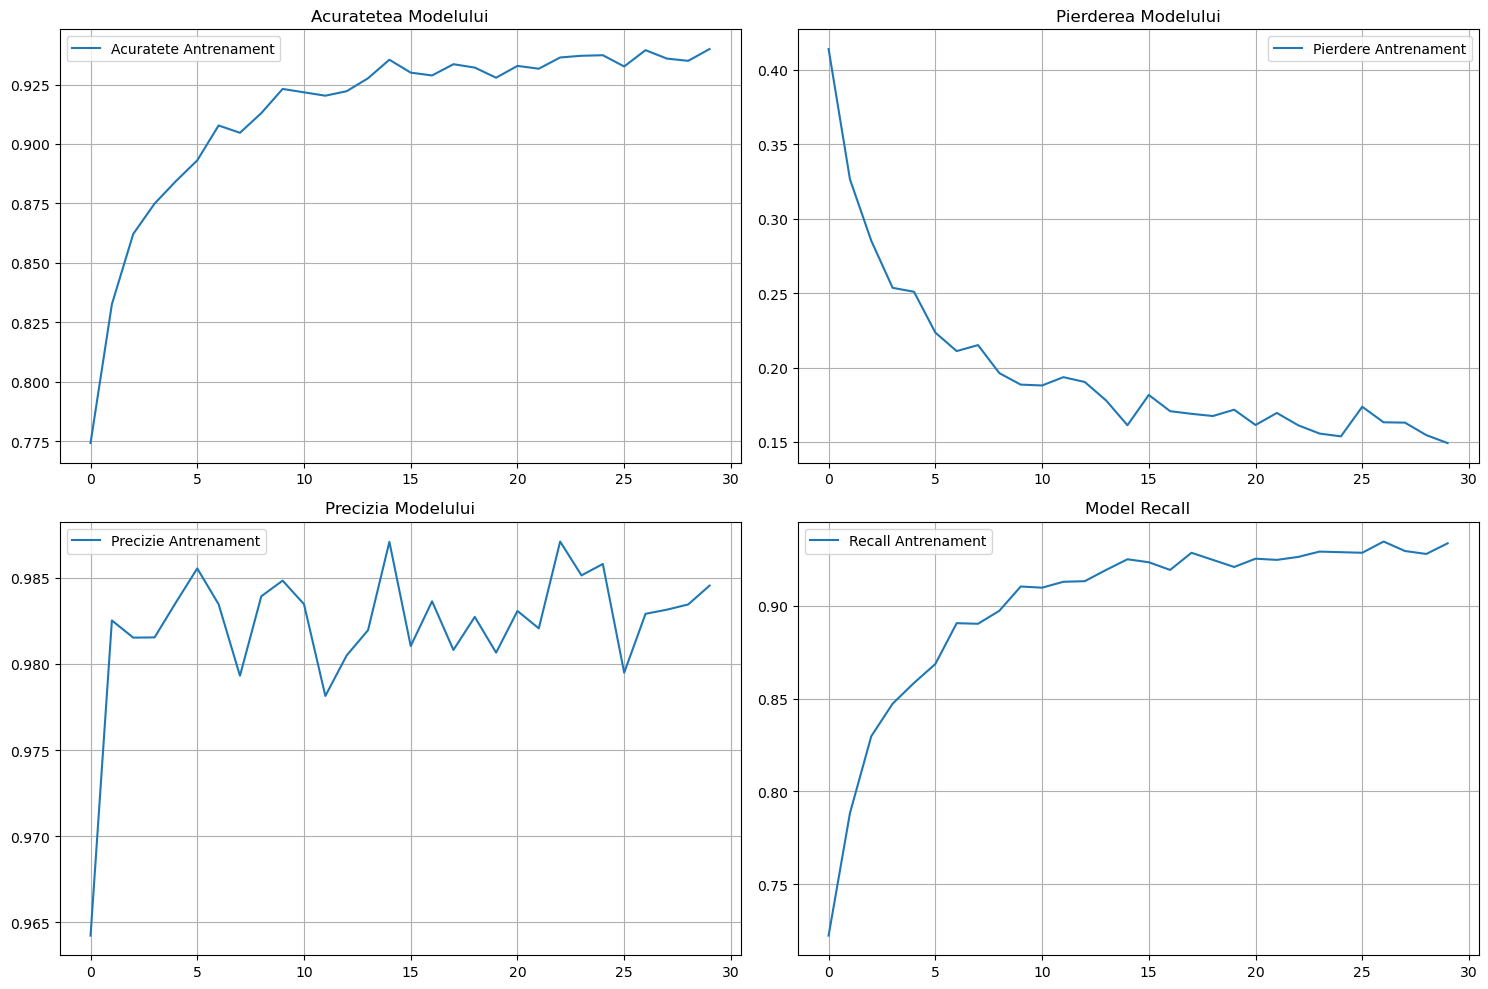

In [61]:
# Graficul performantelor modelului

def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Acuratetea masoara procentajul de predictii corecte; invatam cat de bine se descurca modelul pe datele de antrenament
    axes[0, 0].plot(history.history['accuracy'], label='Acuratete Antrenament')
    axes[0, 0].set_title('Acuratetea Modelului')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Functia de pierdere arata cat de mult scade eroarea modelului pe parcursul epocilor; e bine daca scade constant
    axes[0, 1].plot(history.history['loss'], label='Pierdere Antrenament')
    axes[0, 1].set_title('Pierderea Modelului')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Precizia ne spune cat de corecte sunt prezicerile pozitive ale modelului
    axes[1, 0].plot(history.history['precision'], label='Precizie Antrenament')
    axes[1, 0].set_title('Precizia Modelului')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Recall masoara cat de bine gaseste modelul cazurile pozitive 
    axes[1, 1].plot(history.history['recall'], label='Recall Antrenament')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [62]:
# Evaluare pe setul de test
test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(test_generator)

print(f"\n{'='*50}")
print(f"TEST SET RESULTS:")
print(f"{'='*50}")
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"{'='*50}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.9253 - auc: 0.9944 - loss: 0.2075 - precision: 0.9972 - recall: 0.9021

TEST SET RESULTS:
Test Accuracy:  0.9253 (92.53%)
Test Precision: 0.9972
Test Recall:    0.9021
Test AUC:       0.9944


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step


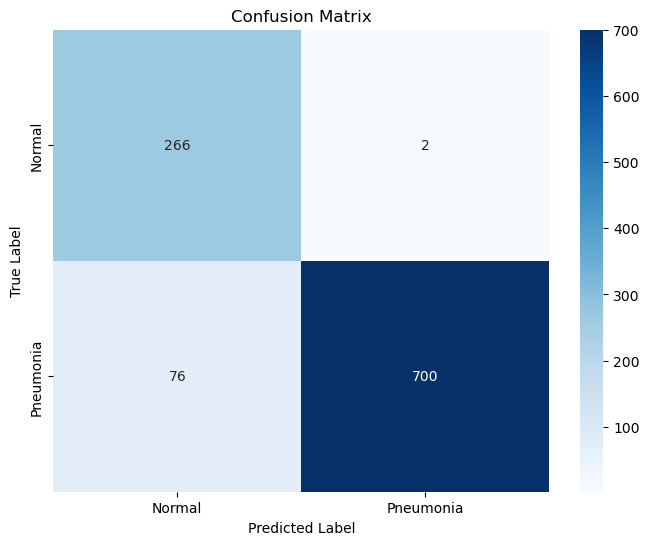


Classification Report:
              precision    recall  f1-score   support

      Normal       0.78      0.99      0.87       268
   Pneumonia       1.00      0.90      0.95       776

    accuracy                           0.93      1044
   macro avg       0.89      0.95      0.91      1044
weighted avg       0.94      0.93      0.93      1044



In [63]:
# Resetam generatorul de test pentru a ne asigura ca predictiile incep de la prima imagine
test_generator.reset()

# Obtinem probabilitatile prezise pentru fiecare imagine din setul de test
# model.predict returneaza un vector de valori intre 0 si 1 (sigmoid output)
y_pred_probs = model.predict(test_generator, verbose=1)

# Convertim probabilitatile in clase binare (0 sau 1), folosind pragul de 0.5
# Daca probabilitatea > 0.5 atunci clasa prezisa = 1 (Pneumonie), altfel 0 (Normal)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Extragem etichetele reale din generatorul de test
y_true = test_generator.classes

# Calculam matricea de confuzie pe baza etichetelor reale si prezise
cm = confusion_matrix(y_true, y_pred)

# Afisam matricea de confuzie ca heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Afisam raportul de clasificare cu metrici precum precizia, recall si F1-score

# Recall: cat de bine identifica modelul cazurile pozitive reale
# Procentajul pozitivilor corect detectati (sensibilitate)
# Recall = TP / (TP + FN)

# F1-score: medie intre precizie si recall
# Echilibreaza detectarea cazurilor pozitive cu evitarea alarmelor false
# F1 = 2 * (Precision * Recall) / (Precision + Recall)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

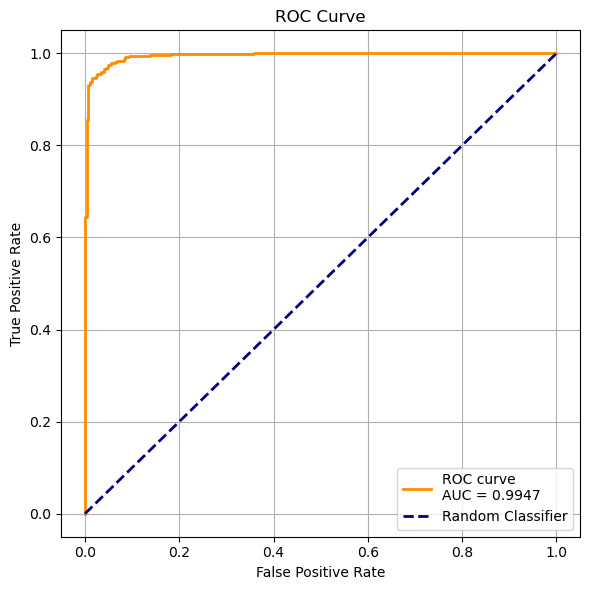

In [64]:
# Calculam rata fals pozitiv (FPR) si rata adevarat pozitiv (TPR) pentru diverse praguri de decizie
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)

# Calculam aria de sub curba ROC (AUC), metric ce masoara calitatea discriminarii modelului
roc_auc_score_val = auc(fpr, tpr)

# Plotam curba ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve\nAUC = {roc_auc_score_val:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Curba ROC (Receiver Operating Characteristic) arata compromisul intre rata adevarat pozitiv (sensibilitate/recall)
# si rata fals pozitiv (alarme false) pentru toate pragurile posibile ale modelului.
# AUC (Area Under the Curve) cuantifica performanta globala a modelului de clasificare.
# O valoare AUC apropiata de 1 indica un model excelent, iar 0.5 inseamna o clasificare la nivel aleator.

## 7. Analiza Erorilor

In [66]:
# Resetam generatorul de test
test_generator.reset()

# Obtinem toate imaginile, probabilitatile si etichetele reale
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Calculam indicii pentru diferitele tipuri de erori
true_positives = np.where((y_pred == 1) & (y_true == 1))[0]      # Corect: pneumonie detectata
true_negatives = np.where((y_pred == 0) & (y_true == 0))[0]      # Corect: normal detectat
false_positives = np.where((y_pred == 1) & (y_true == 0))[0]     # Eroare: normal clasificat ca pneumonie
false_negatives = np.where((y_pred == 0) & (y_true == 1))[0]     # Eroare: pneumonie clasificata ca normal

print(f"{'='*60}")
print(f"ANALIZA DETALIATA A ERORILOR MODELULUI")
print(f"{'='*60}")
print(f"\nTrue Positives (TP):     {len(true_positives)} imagini")
print(f"True Negatives (TN):     {len(true_negatives)} imagini")
print(f"False Positives (FP):    {len(false_positives)} imagini (alarme false)")
print(f"False Negatives (FN):    {len(false_negatives)} imagini (cazuri ratate)")
print(f"{'='*60}")

# Calculam erorile absolute - diferenta intre probabilitatea prezisa si eticheta reala
# (doar pentru cazuri incorecte)
fp_errors = y_pred_probs[false_positives].flatten()                 # Probabilitati pentru FP
fn_errors = y_pred_probs[false_negatives].flatten()                 # Probabilitati pentru FN

# Sortam erorile in ordine descrescatoare - care erori sunt mai severe?
fp_sorted_idx = np.argsort(fp_errors)[::-1]                         # FP cu probabilitate mai mare sunt mai severe
fn_sorted_idx = np.argsort(fn_errors)                               # FN cu probabilitate mai mica sunt mai severe

print(f"\nERORILE CEL MAI GRAVE:")
print(f"\n1. FALSE POSITIVES (Normal clasificat ca PNEUMONIA) - TOP 5:")
print(f"   (Acestia sunt pacientii sanatosi care sunt alertati degeaba)")
for i, idx in enumerate(fp_sorted_idx[:5]):
    actual_idx = false_positives[idx]                               # Index-ul real in test_generator
    prob = y_pred_probs[actual_idx][0]                              # Probabilitatea modelului
    print(f"   {i+1}. Imagine #{actual_idx} | Probabilitate pneumonie: {prob:.4f} (eticheta reala: NORMAL)")

print(f"\n2. FALSE NEGATIVES (PNEUMONIA clasificata ca Normal) - TOP 5:")
print(f"   (Acestia sunt pacientii bolnavi pe care modelul i-a ratat)")
for i, idx in enumerate(fn_sorted_idx[:5]):
    actual_idx = false_negatives[idx]                               # Index-ul real in test_generator
    prob = y_pred_probs[actual_idx][0]                              # Probabilitatea modelului
    print(f"   {i+1}. Imagine #{actual_idx} | Probabilitate pneumonie: {prob:.4f} (eticheta reala: PNEUMONIA)")

print(f"\n{'='*60}")

ANALIZA DETALIATA A ERORILOR MODELULUI

True Positives (TP):     700 imagini
True Negatives (TN):     266 imagini
False Positives (FP):    2 imagini (alarme false)
False Negatives (FN):    76 imagini (cazuri ratate)

ERORILE CEL MAI GRAVE:

1. FALSE POSITIVES (Normal clasificat ca PNEUMONIA) - TOP 5:
   (Aceste sunt pacientii sănătoși care sunt alertaţi degeaba)
   1. Imagine #171 | Probabilitate pneumonie: 0.9254 (eticheta reala: NORMAL)
   2. Imagine #266 | Probabilitate pneumonie: 0.6531 (eticheta reala: NORMAL)

2. FALSE NEGATIVES (PNEUMONIA clasificata ca Normal) - TOP 5:
   (Aceste sunt pacientii bolnavi pe care modelul i-a ratat)
   1. Imagine #325 | Probabilitate pneumonie: 0.0026 (eticheta reala: PNEUMONIA)
   2. Imagine #338 | Probabilitate pneumonie: 0.0078 (eticheta reala: PNEUMONIA)
   3. Imagine #986 | Probabilitate pneumonie: 0.0078 (eticheta reala: PNEUMONIA)
   4. Imagine #805 | Probabilitate pneumonie: 0.0104 (eticheta reala: PNEUMONIA)
   5. Imagine #419 | Probabilit

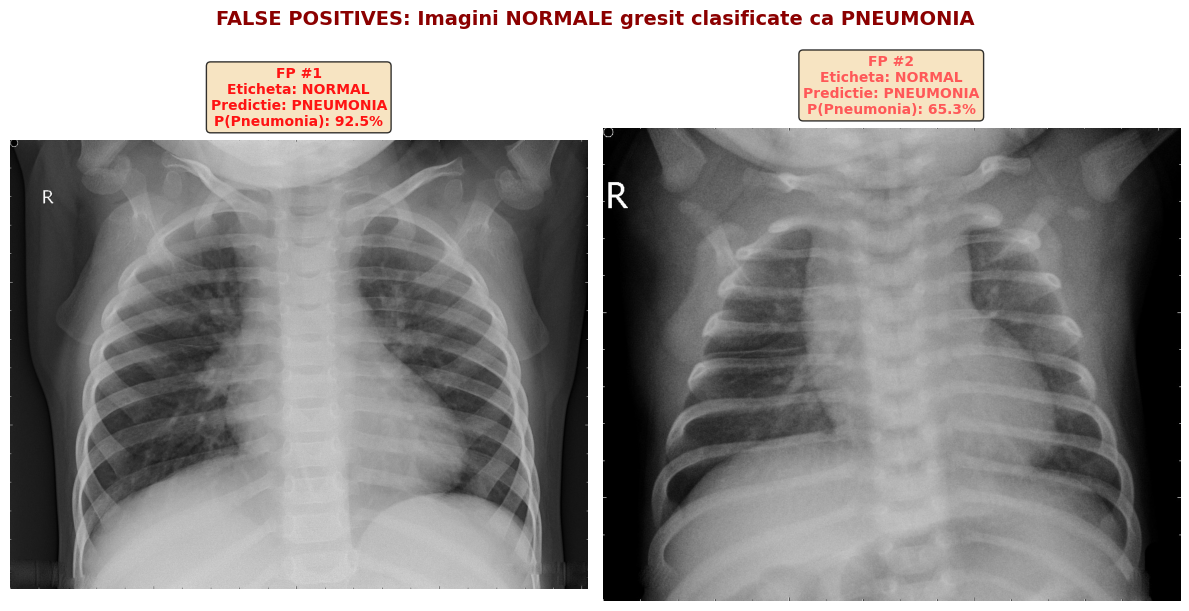

In [74]:
# Vizualizare doar 2 imagini
n_rows = 1
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6))

for idx in range(2):
    if idx < len(fp_sorted_idx):
        error_idx = fp_sorted_idx[idx]
        actual_idx = false_positives[error_idx]
        
        img_path = test_generator.filepaths[actual_idx]
        prob_pneumonia = y_pred_probs[actual_idx][0]
        prob_normal = 1 - prob_pneumonia
        
        img = Image.open(img_path)
        axes[idx].imshow(img, cmap='gray')
        
        color_intensity = prob_pneumonia
        title_color = (1.0, 1 - color_intensity, 1 - color_intensity)
        
        title_text = (
            f"FP #{idx + 1}\n"
            f"Eticheta: NORMAL\n"
            f"Predictie: PNEUMONIA\n"
            f"P(Pneumonia): {prob_pneumonia*100:.1f}%"
        )
        
        axes[idx].set_title(title_text, fontsize=10, fontweight='bold', 
                            color=title_color, pad=10, 
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        axes[idx].axis('off')
    else:
        axes[idx].axis('off')

plt.suptitle("FALSE POSITIVES: Imagini NORMALE gresit clasificate ca PNEUMONIA",
             fontsize=14, fontweight='bold', color='darkred', y=1.05)
plt.tight_layout()
plt.show()


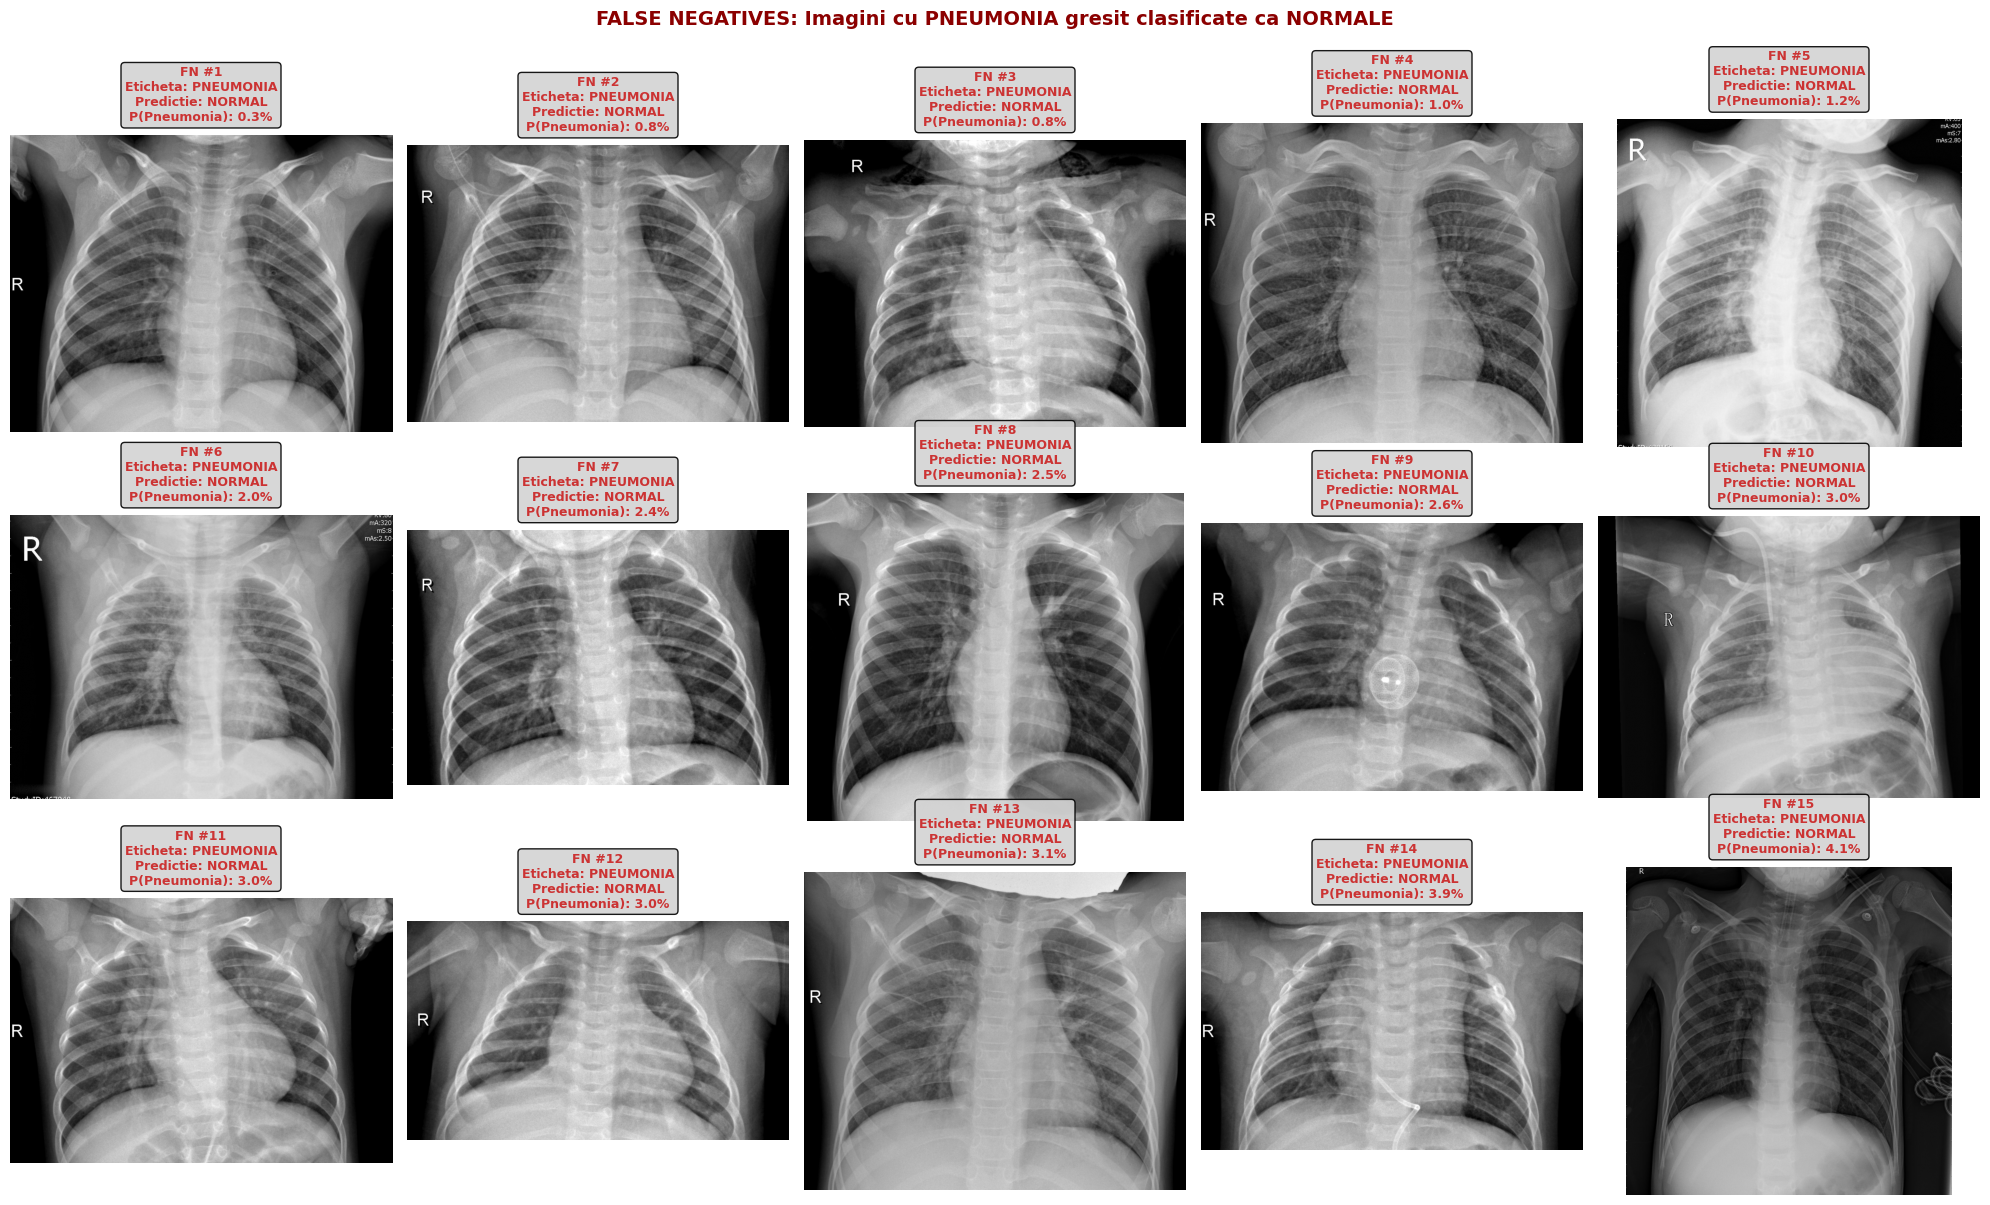

In [71]:
# VIZUALIZARE IMAGINI - FALSE NEGATIVES cu ETICHETE DETALIATE

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))

for row in range(n_rows):
    for col in range(n_cols):
        idx_in_fn = row * n_cols + col
        
        if idx_in_fn < len(fn_sorted_idx):
            error_idx = fn_sorted_idx[idx_in_fn]
            actual_idx = false_negatives[error_idx]
            
            img_path = test_generator.filepaths[actual_idx]
            prob_pneumonia = y_pred_probs[actual_idx][0]
            prob_normal = 1 - prob_pneumonia
            
            img = Image.open(img_path)
            axes[row, col].imshow(img, cmap='gray')
            
            title_color = (0.8, 0.2, 0.2)
            
            title_text = (
                f"FN #{idx_in_fn + 1}\n"
                f"Eticheta: PNEUMONIA\n"
                f"Predictie: NORMAL\n"
                f"P(Pneumonia): {prob_pneumonia*100:.1f}%"
            )
            
            axes[row, col].set_title(title_text, fontsize=9, fontweight='bold', 
                                    color=title_color, pad=10,
                                    bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.9))
            axes[row, col].axis('off')
        else:
            axes[row, col].axis('off')

plt.suptitle("FALSE NEGATIVES: Imagini cu PNEUMONIA gresit clasificate ca NORMALE",
             fontsize=14, fontweight='bold', color='darkred', y=1)
plt.tight_layout()
plt.show()

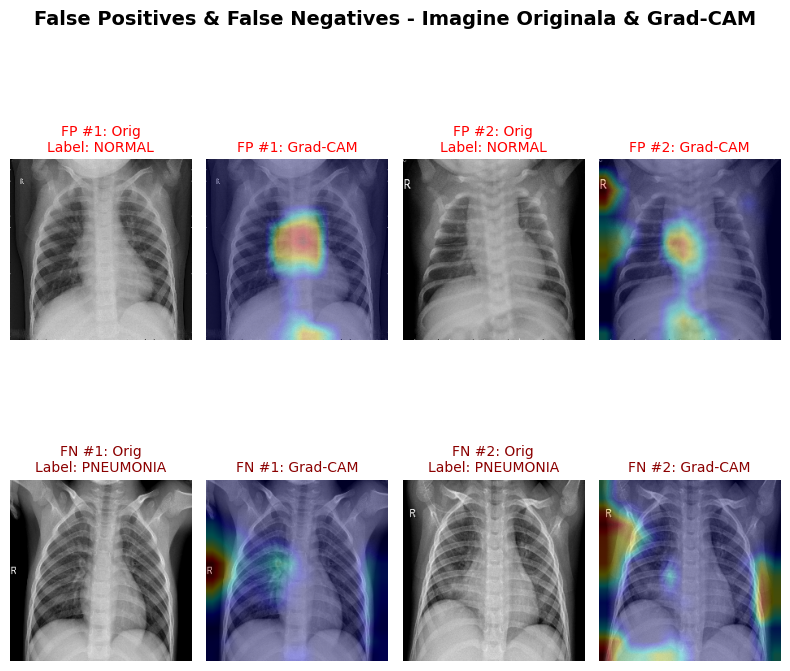

In [82]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image

def generate_gradcam(model, img_array, layer_name='block5_conv3', pred_idx=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_idx is None:
            pred_idx = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_idx]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    cam = conv_outputs @ pooled_grads[..., tf.newaxis]
    cam = tf.squeeze(cam)
    cam = tf.maximum(cam, 0) / tf.math.reduce_max(cam)
    return cam.numpy()

num_samples_fp = min(2, len(fp_sorted_idx))
num_samples_fn = min(2, len(fn_sorted_idx))

fig, axes = plt.subplots(2, max(num_samples_fp, num_samples_fn)*2, figsize=(4*max(num_samples_fp, num_samples_fn), 8))

for i in range(num_samples_fp):
    idx = fp_sorted_idx[i]
    actual_idx = false_positives[idx]
    
    img_path = test_generator.filepaths[actual_idx]
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img_disp = tf.cast(img, tf.uint8).numpy()
    img_normalized = img / 255.0
    img_batch = tf.expand_dims(img_normalized, 0)
    
    cam = generate_gradcam(model, img_batch, layer_name='block5_conv3')
    cam_resized = cv2.resize(cam, (224, 224))
    cam_heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    cam_heatmap_rgb = cv2.cvtColor(cam_heatmap, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img_disp, 0.7, cam_heatmap_rgb, 0.3, 0)
    
    axes[0, i*2].imshow(img_disp)
    axes[0, i*2].set_title(f"FP #{i+1}: Orig\nLabel: NORMAL", fontsize=10, color='red')
    axes[0, i*2].axis('off')
    axes[0, i*2+1].imshow(superimposed)
    axes[0, i*2+1].set_title(f"FP #{i+1}: Grad-CAM", fontsize=10, color='red')
    axes[0, i*2+1].axis('off')

for i in range(num_samples_fn):
    idx = fn_sorted_idx[i]
    actual_idx = false_negatives[idx]
    
    img_path = test_generator.filepaths[actual_idx]
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img_disp = tf.cast(img, tf.uint8).numpy()
    img_normalized = img / 255.0
    img_batch = tf.expand_dims(img_normalized, 0)
    
    cam = generate_gradcam(model, img_batch, layer_name='block5_conv3')
    cam_resized = cv2.resize(cam, (224, 224))
    cam_heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    cam_heatmap_rgb = cv2.cvtColor(cam_heatmap, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img_disp, 0.7, cam_heatmap_rgb, 0.3, 0)
    
    axes[1, i*2].imshow(img_disp)
    axes[1, i*2].set_title(f"FN #{i+1}: Orig\nLabel: PNEUMONIA", fontsize=10, color='darkred')
    axes[1, i*2].axis('off')
    axes[1, i*2+1].imshow(superimposed)
    axes[1, i*2+1].set_title(f"FN #{i+1}: Grad-CAM", fontsize=10, color='darkred')
    axes[1, i*2+1].axis('off')

plt.suptitle("False Positives & False Negatives - Imagine Originala & Grad-CAM",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Concluzii

In acest proiect am construit si antrenat un model de clasificare a imaginilor radiologice folosind arhitectura VGG16 prin transfer learning. Modelul a reusit sa diferentieze imaginile NORMAL de cele PNEUMONIA cu o acuratete ridicata si cu un recall foarte bun pentru clasa PNEUMONIA, ceea ce este important in detectarea timpurie a afectiunilor pulmonare. Procesul de antrenare a inclus augmentarea datelor, folosirea de callback-uri, regularizare si ajustarea ponderilor claselor, toate contribuind la stabilitatea si performanta finala a modelului. Rezultatele obtinute arata ca abordarea folosita este eficienta si poate reprezenta baza pentru dezvoltari ulterioare sau pentru aplicatii practice in analiza automata a radiografiilor.